# OpenCV Video Processing

## Reading Video Files

`cv2.VideoCapture` works with **files**, **webcams** (pass an integer index — `0` for the first camera), and **network streams** (RTSP/HTTP URLs). The API is identical in all three cases: open, read frames in a loop, release when done.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

In [ ]:
# Download a sample video
video_url = "https://www.w3schools.com/html/mov_bbb.mp4"
video_path = "../artifacts/outputs/sample_video.mp4"
os.makedirs(os.path.dirname(video_path), exist_ok=True)

if not os.path.exists(video_path):
    urllib.request.urlretrieve(video_url, video_path)
    print(f"Downloaded: {video_path}")

In [ ]:
# Open video file
cap = cv2.VideoCapture(video_path)

# Get video properties using CAP_PROP_* constants.
# Other useful constants: CAP_PROP_POS_FRAMES (jump to a frame),
# CAP_PROP_BRIGHTNESS / CONTRAST / SATURATION (camera controls only).
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Resolution: {width}x{height}")
print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Duration: {total_frames/fps:.2f} seconds")

# Releases the file handle so the OS can free the resource.
# Always call this — even if you read only a few frames.
cap.release()

Resolution: 320x176
FPS: 25.0
Total frames: 250
Duration: 10.00 seconds


## Frame-by-Frame Processing

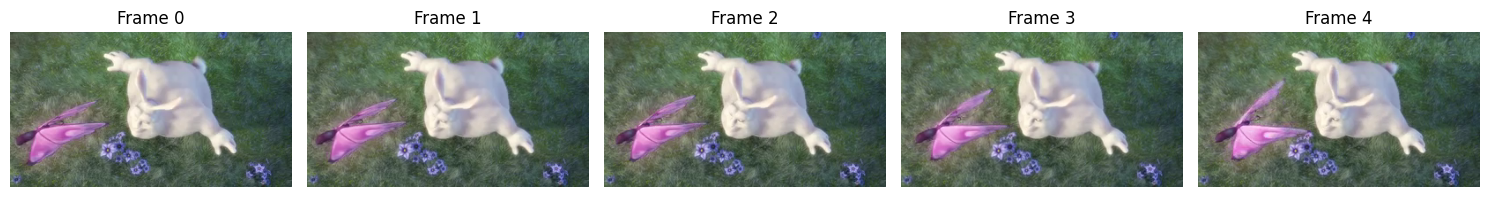

In [ ]:
cap = cv2.VideoCapture(video_path)

# Read first 5 frames.
# cap.read() returns a tuple (ret, frame):
#   ret   — bool; False when the video ends or the source is unavailable.
#   frame — the decoded image in BGR format, or None when ret is False.
frames = []
for i in range(5):
    ret, frame = cap.read()
    if ret:
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Releases the video file so the OS can free the resource.
cap.release()

# Display frames
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (ax, frame) in enumerate(zip(axes, frames)):
    ax.imshow(frame)
    ax.set_title(f'Frame {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Applying Filters to Video

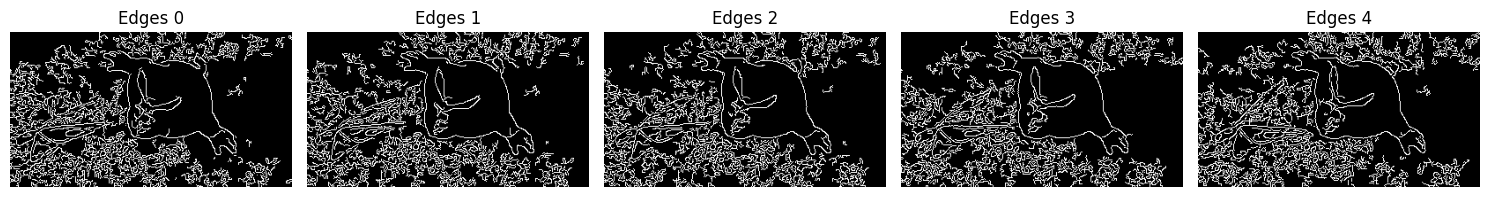

In [ ]:
def process_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Canny uses two hysteresis thresholds:
    #   50  — lower bound: edges below this are always discarded.
    #   150 — upper bound: edges above this are always kept.
    # Pixels in-between are kept only if they connect to a strong (>150) edge.
    # Rule of thumb: upper ≈ 2–3× lower.
    edges = cv2.Canny(gray, 50, 150)
    return edges

cap = cv2.VideoCapture(video_path)

# Process frames
processed_frames = []
for i in range(5):
    ret, frame = cap.read()
    if ret:
        processed = process_frame(frame)
        processed_frames.append(processed)

cap.release()

# Display
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (ax, frame) in enumerate(zip(axes, processed_frames)):
    ax.imshow(frame, cmap='gray')
    ax.set_title(f'Edges {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Writing Video Output

`VideoWriter` encodes frames into a compressed video file. The key parameter is the **fourcc codec** — a 4-character code identifying the compression algorithm:

| Code | Algorithm | Container |
|------|-----------|-----------|
| `mp4v` | MPEG-4 Part 2 | `.mp4` |
| `avc1` / `H264` | H.264 | `.mp4` |
| `XVID` | Xvid/MPEG-4 | `.avi` |
| `MJPG` | Motion JPEG | `.avi` |

Codec availability depends on what is installed on your system.

In [ ]:
cap = cv2.VideoCapture(video_path)

output_path = '../artifacts/outputs/output_edges.mp4'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
# VideoWriter_fourcc(*'mp4v') is shorthand for VideoWriter_fourcc('m','p','4','v').
# The * unpacks the string into four separate char arguments.
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# VideoWriter(filename, fourcc, fps, frameSize, isColor)
# isColor=False: frames are single-channel (grayscale). Must match what you write.
# frameSize (width, height) must match exactly — mismatch silently corrupts output.
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height), isColor=False)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    edges = process_frame(frame)
    out.write(edges)

# cap.release() frees the input file handle.
# out.release() flushes encoder buffers and writes the final container metadata
# (the MOOV atom in MP4) — omitting this produces an unplayable file.
cap.release()
out.release()

print(f"Video saved to: {output_path}")

# Cleanup
# for f in [video_path, output_path]:
#     if os.path.exists(f):
#         os.remove(f)

Video saved to: ../artifacts/outputs/output_edges.mp4


## Webcam Capture

> **Note:** This cell opens a GUI window and blocks execution until you press `q`. It requires a **display** and a **physical camera** — it will not run in headless or cloud notebook environments.

In [ ]:
# ⚠️ Requires a GUI display and a physical webcam.
# Run this in a local environment — not a headless server or cloud notebook.

# Index 0 = first detected camera. Use 1, 2 ... for additional cameras.
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.imshow('Webcam', frame)

    # waitKey(1): wait 1 ms for a keypress — also needed to refresh the GUI window.
    # & 0xFF masks to 8 bits for compatibility across platforms.
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Releases the camera so other applications can use it.
cap.release()
# Closes all windows created by cv2.imshow().
cv2.destroyAllWindows()

[ WARN:0@5.846] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[video4linux2,v4l2 @ 0x12e61ac0] ioctl(VIDIOC_G_INPUT): Inappropriate ioctl for device
[ERROR:0@5.847] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


## Background Subtraction

Background subtraction identifies which pixels in a frame are moving (foreground) by comparing each frame against a learned model of the static scene (background).

Parameter intuition:

- `history` — the number of past frames used to update the background model. Short history (50–100 frames): adapts quickly but may absorb slow-moving objects as background. Long history (500+): stable background model for static cameras.
- `varThreshold` — the Mahalanobis distance beyond which a pixel is classified as foreground. Low value: sensitive, detects subtle movement but also noise. High value: only large deviations are flagged as foreground.
- `detectShadows=True`: shadows are labelled as a separate class (grey pixels, value 127) rather than being merged with foreground. Useful if you want to ignore shadows in post-processing.


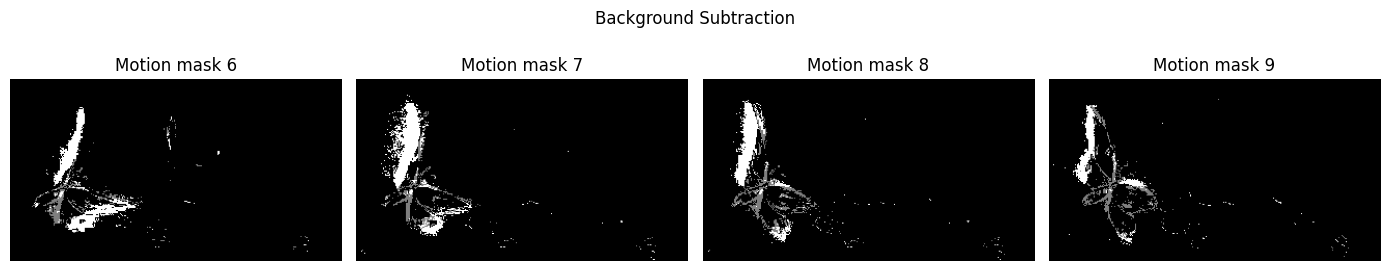

In [ ]:
cap = cv2.VideoCapture(video_path)

# MOG2 = Mixture of Gaussians v2.
#   history      — number of past frames used to build the background model.
#                  Higher = slower to adapt (good for static cameras; bad when lighting changes).
#   varThreshold — Mahalanobis distance threshold. Higher = less sensitive (fewer false alarms).
bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50)

masks = []
for i in range(10):
    ret, frame = cap.read()
    if not ret:
        break

    # apply() updates the model AND returns the foreground mask.
    # Mask values: 255 = moving foreground, 0 = background, 127 = detected shadow.
    fg_mask = bg_subtractor.apply(frame)
    masks.append(fg_mask)

cap.release()

# Show last few masks (after model learns background)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(masks[6+i], cmap='gray')
    ax.set_title(f'Motion mask {6+i}')
    ax.axis('off')
plt.suptitle('Background Subtraction')
plt.tight_layout()
plt.show()

## Summary

| Task | Function |
|------|----------|
| Read video | `cv2.VideoCapture(path)` |
| Write video | `cv2.VideoWriter(path, fourcc, fps, size)` |
| Read frame | `cap.read()` |
| Video properties | `cap.get(cv2.CAP_PROP_*)` |
| Background subtraction | `cv2.createBackgroundSubtractorMOG2()` |